In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data

sns.set_style("whitegrid")

In [3]:
df = load_data("../data/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [4]:
df.shape

(10000, 21)

In [5]:
df.dtypes

CustomerID                 str
Age                      int64
Gender                     str
Province                   str
VehicleType                str
AnnualIncome             int64
RiskScore                int64
AnnualPremium            int64
Deductible               int64
NCD                      int64
PastClaims               int64
Claimed                   bool
ClaimAmount            float64
TotalPremium             int64
TotalClaims            float64
CoverType                  str
AutoMake                   str
VehicleModel               str
CustomValueEstimate      int64
ZipCode                  int64
TransactionDate            str
dtype: object

In [6]:
df.describe()

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000


In [7]:
df["LossRatio"] = (
    df["TotalClaims"] / df["TotalPremium"]
)

df["Margin"] = (
    df["TotalPremium"] - df["TotalClaims"]
)

In [8]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [9]:
(df.isnull().mean() * 100).sort_values(ascending=False)

CustomerID             0.0
Age                    0.0
Gender                 0.0
Province               0.0
VehicleType            0.0
AnnualIncome           0.0
RiskScore              0.0
AnnualPremium          0.0
Deductible             0.0
NCD                    0.0
PastClaims             0.0
Claimed                0.0
ClaimAmount            0.0
TotalPremium           0.0
TotalClaims            0.0
CoverType              0.0
AutoMake               0.0
VehicleModel           0.0
CustomValueEstimate    0.0
ZipCode                0.0
TransactionDate        0.0
LossRatio              0.0
Margin                 0.0
dtype: float64

The dataset contains 10,000 insurance records with customer, vehicle, policy, and claim information. Data types are mostly correctly assigned, with numerical features stored as integers/floats and categorical features as strings. The TransactionDate column will need to be converted to datetime format for time-series analysis.

Descriptive statistics show large variation in financial variables such as TotalClaims and CustomValueEstimate, indicating the presence of potential outliers. Most policies have zero claims, while a small number contain very high claim amounts, which is common in insurance datasets.

The data quality assessment shows no missing values across all columns, meaning the dataset is clean and suitable for further analysis without major preprocessing.

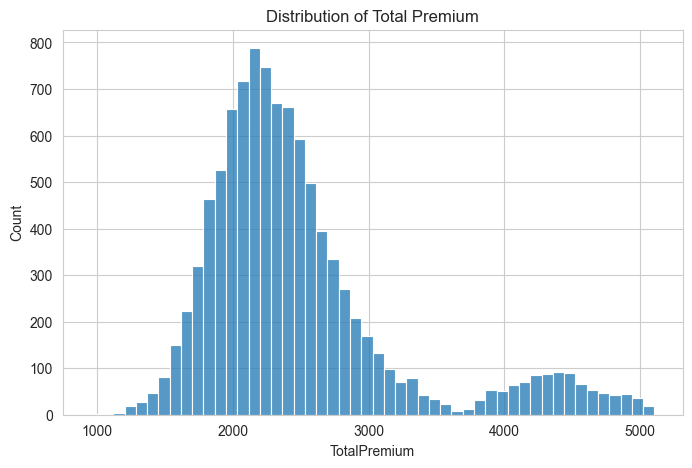

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["TotalPremium"], bins=50)

plt.title("Distribution of Total Premium")
plt.show()

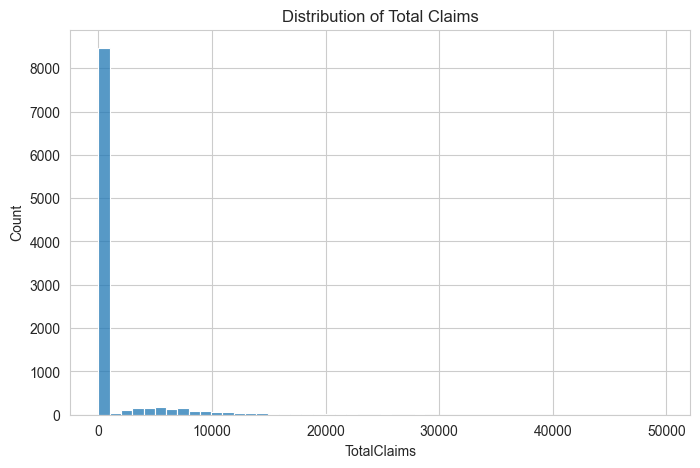

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["TotalClaims"], bins=50)

plt.title("Distribution of Total Claims")
plt.show()

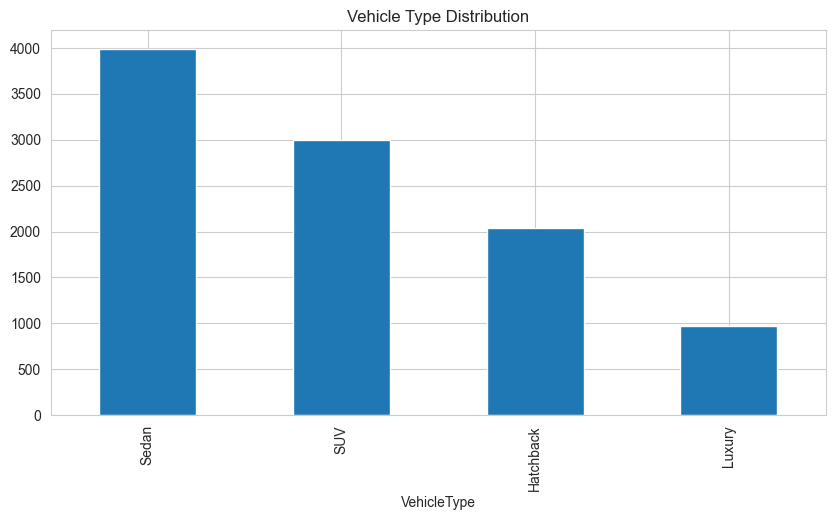

In [13]:
plt.figure(figsize=(10,5))

df["VehicleType"].value_counts().plot(kind="bar")

plt.title("Vehicle Type Distribution")

plt.show()

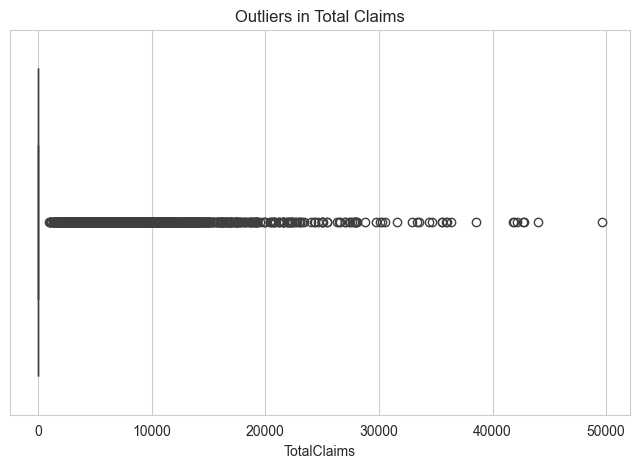

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["TotalClaims"])

plt.title("Outliers in Total Claims")

plt.show()

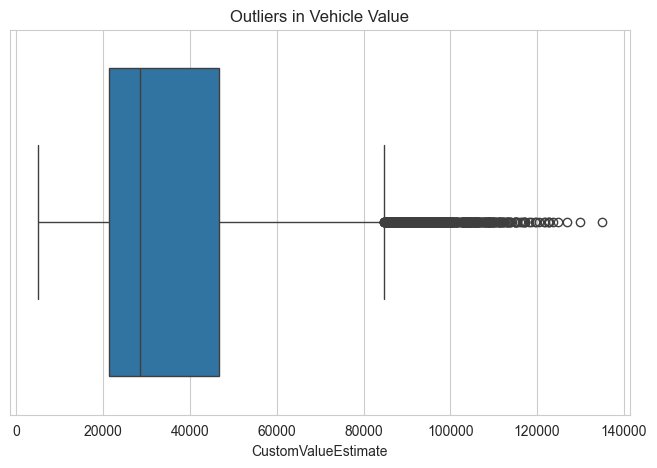

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["CustomValueEstimate"])

plt.title("Outliers in Vehicle Value")

plt.show()

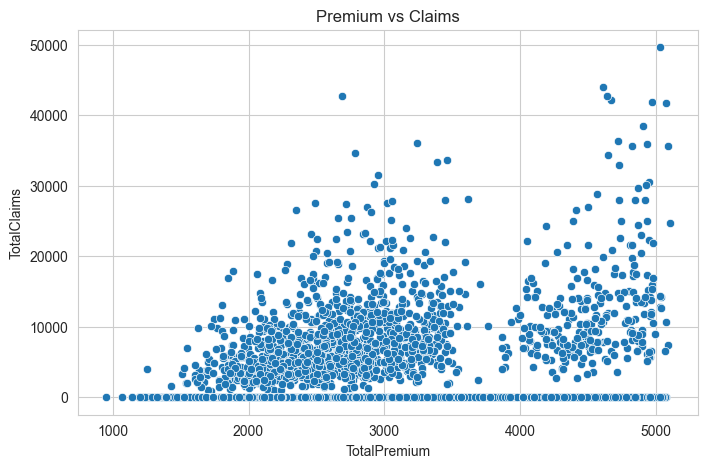

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims"
)

plt.title("Premium vs Claims")

plt.show()

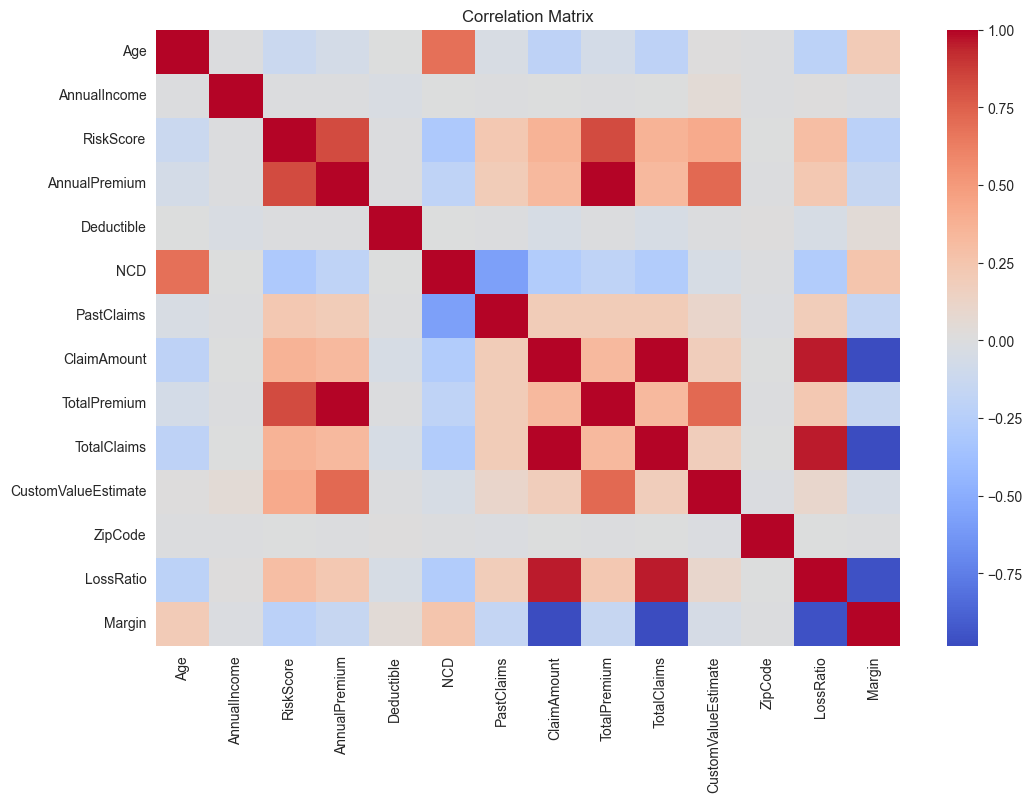

In [17]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

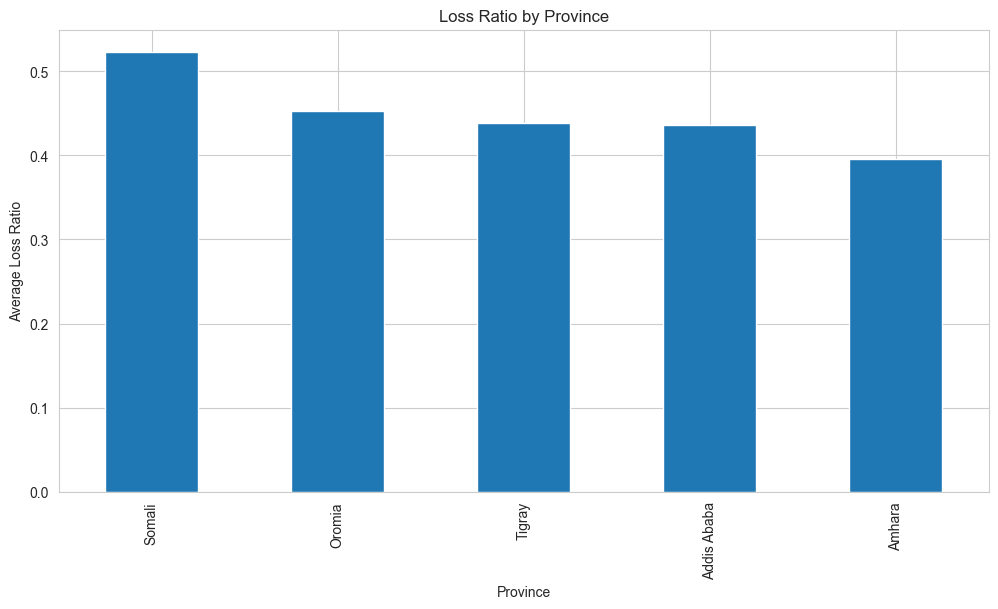

In [18]:
province_loss = (
    df.groupby("Province")["LossRatio"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

province_loss.plot(kind="bar")

plt.title("Loss Ratio by Province")

plt.ylabel("Average Loss Ratio")

plt.show()

In [20]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

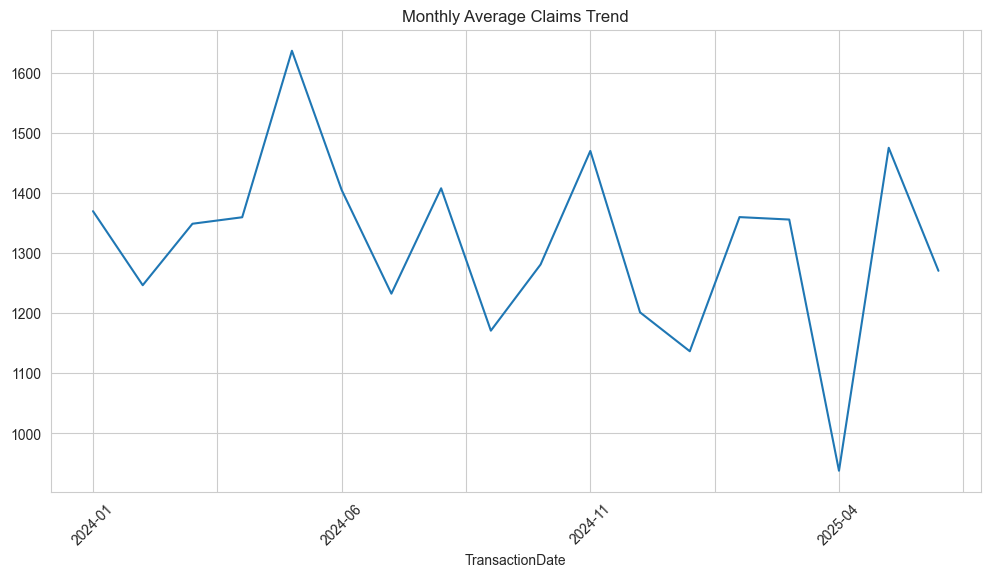

In [21]:
monthly_claims = (
    df.groupby(
        df["TransactionDate"].dt.to_period("M")
    )["TotalClaims"]
    .mean()
)

monthly_claims.index = monthly_claims.index.astype(str)

plt.figure(figsize=(12,6))

monthly_claims.plot()

plt.title("Monthly Average Claims Trend")

plt.xticks(rotation=45)

plt.show()

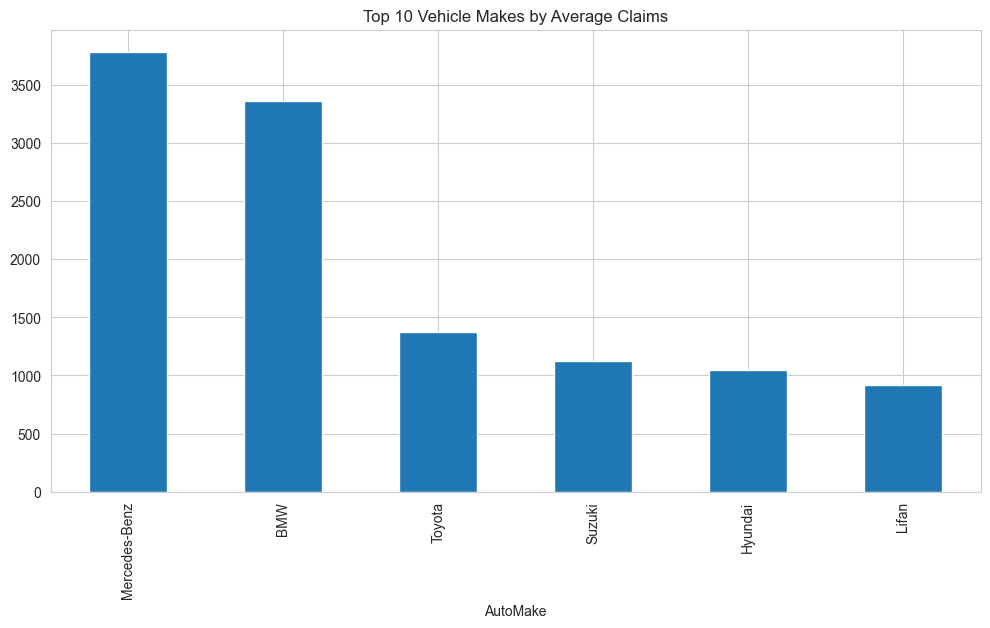

In [23]:
vehicle_claims = (
    df.groupby("AutoMake")["TotalClaims"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

vehicle_claims.plot(kind="bar")

plt.title("Top 10 Vehicle Makes by Average Claims")

plt.show()

The portfolio loss ratio indicates the relationship between total claims and total premiums collected. The analysis shows that loss ratios vary across provinces, vehicle types, and gender groups, suggesting that insurance risk is not evenly distributed across the portfolio. Certain provinces and vehicle categories appear to generate higher claim costs, which may require differentiated pricing strategies.

The distributions of TotalClaims and CustomValueEstimate are highly right-skewed. Most policies have low or zero claim amounts, while a small number of policies contain extremely high claim values. Boxplots also reveal significant outliers in both claim amounts and vehicle values, which could strongly influence averages and predictive models if not handled carefully.

The temporal analysis shows fluctuations in claim frequency and severity over the 18-month period. Some months exhibit higher average claim amounts than others, suggesting possible seasonal or operational trends in insurance risk. Monitoring these trends can help the company improve forecasting and pricing decisions.

Certain vehicle makes and models are associated with higher average claim amounts, indicating greater insurance risk. High-value or frequently claimed vehicle types may require higher premiums or stricter underwriting policies, while lower-risk vehicles could be targeted for competitive pricing and marketing campaigns.